## BERGER STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

berger=pd.read_csv('../stock_data/berger.csv')
berger=berger.drop(columns=['high_price','low_price'])
berger.rename(columns={'trade_date':'date'},inplace=True)
berger['date']=pd.to_datetime(berger['date'])
berger['month']=berger['date'].dt.month
berger['quarter']=berger['date'].dt.quarter
berger['year']=berger['date'].dt.year

berger

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42840,BERGER,2017-01-03,6.4,6.4,24438,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43400,BERGER,2017-01-04,6.4,6.4,48577,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43510,BERGER,2017-01-05,6.4,6.4,7807,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43620,BERGER,2017-01-06,6.4,6.4,26164,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43710,BERGER,2017-01-09,6.4,6.4,3300,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298030,BERGER,2026-07-13,147.6,147.6,14936,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298468,BERGER,2026-07-14,147.6,147.6,14929,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298906,BERGER,2026-07-15,147.6,147.6,3324,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299344,BERGER,2026-07-16,147.6,147.6,20649,2026-07-16T15:10:03.113936+00:00,7,3,2026


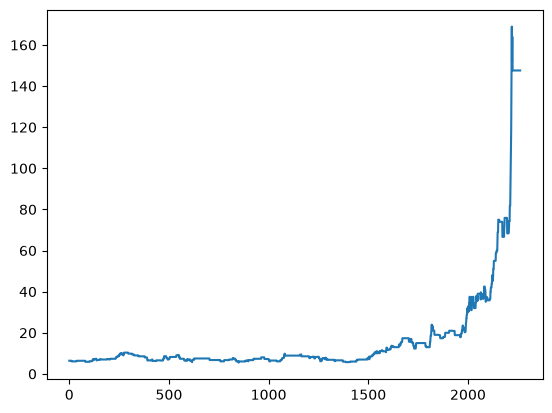

In [2]:
import matplotlib.pyplot as plt

plt.plot(berger['close_price'])
plt.show()

In [3]:
berger_end_month_df = (
    berger
    .sort_values("date")
    .groupby(berger["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

berger_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45410,BERGER,2017-01-31,6.08,6.08,56000,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47232,BERGER,2017-02-28,6.38,6.38,1257,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49348,BERGER,2017-03-31,6.38,6.38,4400,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51175,BERGER,2017-04-28,5.88,5.88,433,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53098,BERGER,2017-05-31,6.17,6.17,110660,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35267,BERGER,2026-03-31,75.90,75.90,800530,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281094,BERGER,2026-04-30,81.75,81.75,1971247,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284160,BERGER,2026-05-29,147.60,147.60,79772,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294088,BERGER,2026-06-30,147.60,147.60,9934,2026-06-30T15:10:03.08168+00:00,6,2,2026


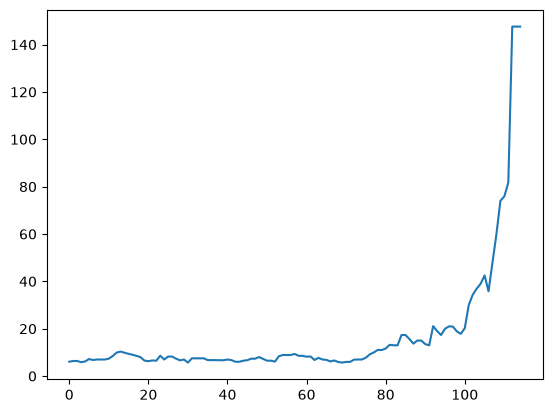

In [4]:
plt.plot(berger_end_month_df['close_price'])
plt.show()

In [5]:
berger_end_month_df['returns']=berger_end_month_df['close_price'].pct_change()*100
berger_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45410,BERGER,2017-01-31,6.08,6.08,56000,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47232,BERGER,2017-02-28,6.38,6.38,1257,2026-04-08T02:44:45.006295+00:00,2,1,2017,4.934211
2,49348,BERGER,2017-03-31,6.38,6.38,4400,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51175,BERGER,2017-04-28,5.88,5.88,433,2026-04-08T02:51:55.619599+00:00,4,2,2017,-7.836991
4,53098,BERGER,2017-05-31,6.17,6.17,110660,2026-04-08T02:52:57.421655+00:00,5,2,2017,4.931973
...,...,...,...,...,...,...,...,...,...,...,...
110,35267,BERGER,2026-03-31,75.90,75.90,800530,2026-03-31T15:00:02.085058+00:00,3,1,2026,2.567568
111,281094,BERGER,2026-04-30,81.75,81.75,1971247,2026-04-30T15:00:02.170664+00:00,4,2,2026,7.707510
112,284160,BERGER,2026-05-29,147.60,147.60,79772,2026-05-29T15:00:02.455558+00:00,5,2,2026,80.550459
113,294088,BERGER,2026-06-30,147.60,147.60,9934,2026-06-30T15:10:03.08168+00:00,6,2,2026,0.000000


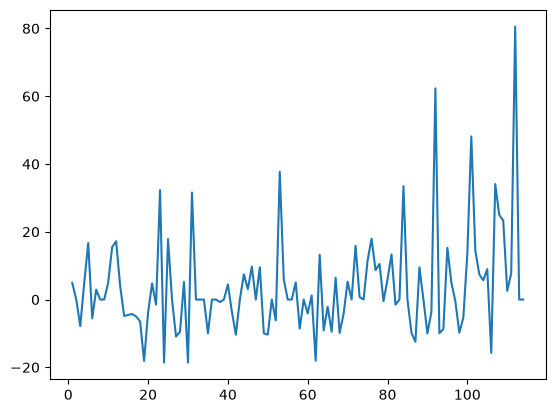

In [6]:
plt.plot(berger_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(berger_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.674794954906826), np.float64(4.0799282672854323e-19), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(838.4759266456979))
stationary


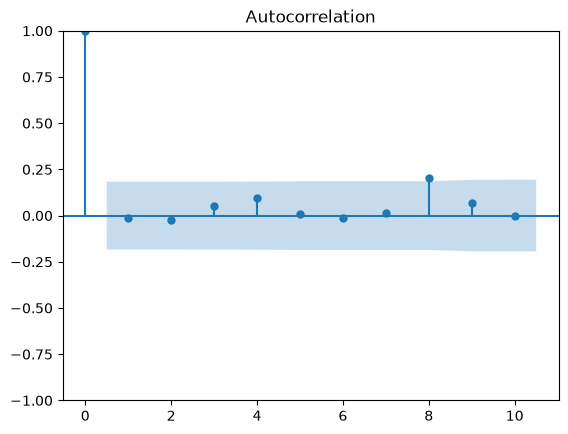

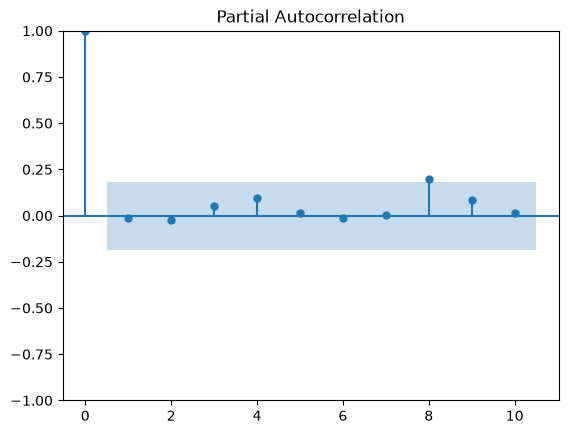

In [ ]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(berger_end_month_df['returns'].dropna(), lags=10)
plot_pacf(berger_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=berger_end_month_df['close_price'][:-10]
test=berger_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -4.075308706572867]
[0, 0, 0, 0, 0, 1, -2.950909576446695]
[0, 0, 0, 0, 0, 2, -2.432105815131869]
[0, 0, 0, 0, 1, 0, -2.092880227013373]
[0, 0, 0, 0, 1, 1, -1.9630941020398773]
[0, 0, 0, 0, 1, 2, -1.756602736391565]
[0, 0, 0, 0, 2, 0, -1.480790655164098]
[0, 0, 0, 0, 2, 1, -1.589120393118471]
[0, 0, 0, 0, 2, 2, -1.4491608421359694]
[0, 0, 0, 1, 0, 0, -2.1796807213828986]
[0, 0, 0, 1, 0, 1, -2.0634425380192343]
[0, 0, 0, 1, 0, 2, -1.8803586869249278]
[0, 0, 0, 1, 1, 0, -1.834823522640598]
[0, 0, 0, 1, 1, 1, -1.796693497993906]
[0, 0, 0, 1, 1, 2, -1.7062369894862726]
[0, 0, 0, 1, 2, 0, -1.576705224726075]
[0, 0, 0, 1, 2, 1, -1.51096242136407]
[0, 0, 0, 1, 2, 2, -1.499379959457345]
[0, 0, 0, 2, 0, 0, -1.976427589799898]
[0, 0, 0, 2, 0, 1, -1.9601304306174838]
[0, 0, 0, 2, 0, 2, -1.947046078672848]
[0, 0, 0, 2, 1, 0, -1.7589056249416215]
[0, 0, 0, 2, 1, 1, -1.7158699307697352]
[0, 0, 0, 2, 1, 2, -1.7133852812966]
[0, 0, 0, 2, 2, 0, -1.4610318482949398]
[0, 0, 0, 2, 2, 1,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-10.147716
177,0,2,0,1,2,0,-6.624663
411,1,2,0,0,2,0,-5.548525
169,0,2,0,0,2,1,-4.921006
165,0,2,0,0,1,0,-4.132350
...,...,...,...,...,...,...,...
649,2,2,0,0,0,1,-0.206937
666,2,2,0,2,0,0,-0.202211
667,2,2,0,2,0,1,-0.197853
659,2,2,0,1,0,2,-0.187393


Not good enough. Lets check the returns.

In [14]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=berger_end_month_df['returns'].dropna()[:-10]
test=berger_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.42994351665015884]
[0, 0, 0, 0, 0, 1, -0.42023486546725963]
[0, 0, 0, 0, 0, 2, -0.3966368079236662]
[0, 0, 0, 0, 1, 0, -0.40957301369573185]
[0, 0, 0, 0, 1, 1, -0.24953216191462202]
[0, 0, 0, 0, 1, 2, -0.20761996603312838]
[0, 0, 0, 0, 2, 0, -2.0571889727412547]
[0, 0, 0, 0, 2, 1, -0.48619084336118035]
[0, 0, 0, 0, 2, 2, -0.12570546288767637]
[0, 0, 0, 1, 0, 0, -0.41913704342433955]
[0, 0, 0, 1, 0, 1, -0.361535845953354]
[0, 0, 0, 1, 0, 2, -0.37383873115600497]
[0, 0, 0, 1, 1, 0, -0.11056607347513348]
[0, 0, 0, 1, 1, 1, -0.21468944026329173]
[0, 0, 0, 1, 1, 2, -0.23888772256279434]
[0, 0, 0, 1, 2, 0, -0.6532859684198633]
[0, 0, 0, 1, 2, 1, -0.14157854011242677]
[0, 0, 0, 1, 2, 2, -0.11658801767452354]
[0, 0, 0, 2, 0, 0, -0.38319363242479376]
[0, 0, 0, 2, 0, 1, -0.3729794370103072]
[0, 0, 0, 2, 0, 2, -0.38517149615082635]
[0, 0, 0, 2, 1, 0, -0.036456991105835224]
[0, 0, 0, 2, 1, 1, -0.20268506179531043]
[0, 0, 0, 2, 1, 2, -0.23247934962502348]
[0, 0, 0, 2, 2, 0, -0

In [15]:
train

1       4.934211
2       0.000000
3      -7.836991
4       4.931973
5      16.693679
         ...    
100    13.445378
101    48.148148
102    14.500000
103     7.423581
104     5.691057
Name: returns, Length: 104, dtype: float64

In [16]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
168,0,2,0,0,2,0,-1228.983983
177,0,2,0,1,2,0,-844.552621
411,1,2,0,0,2,0,-603.853801
169,0,2,0,0,2,1,-462.202827
165,0,2,0,0,1,0,-354.963275
...,...,...,...,...,...,...,...
725,2,2,2,2,2,1,0.087832
241,0,2,2,2,2,1,0.088714
721,2,2,2,2,1,0,0.142481
479,1,2,2,2,1,0,0.143849


We might have to make use of returns in this case because the trending data didnt give a ny positive results.

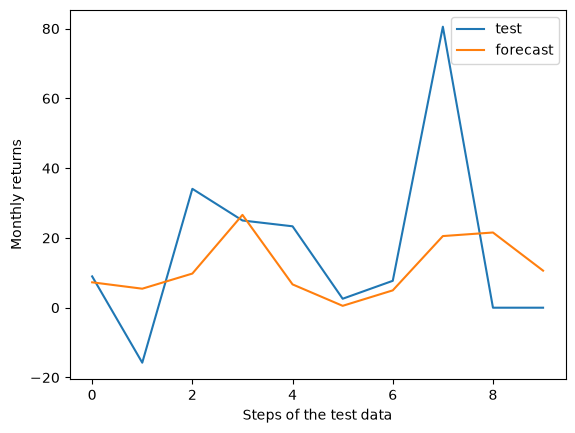

r2_score:  0.14427066255541876
rmse:  23.4821462575253


In [17]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=berger_end_month_df['returns'].dropna()[:-10]
y_test=berger_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,2), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))

In [18]:
berger_end_month_df.returns.describe()

count    114.000000
mean       3.765858
std       15.014726
min      -18.604651
25%       -4.490226
50%        0.000000
75%        7.640137
max       80.550459
Name: returns, dtype: float64

RMSE is greater than STD which is concerning. Lets check the next best [1	2	2	2	1	0]

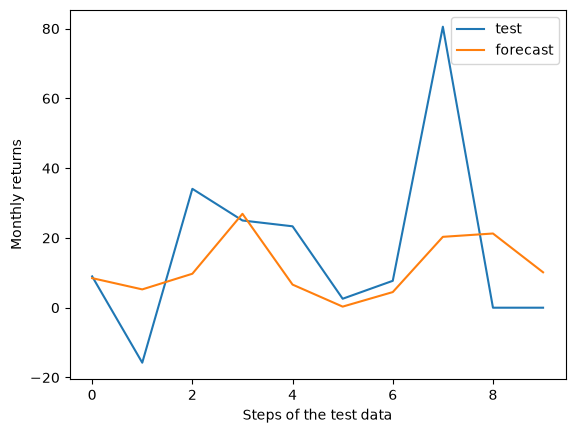

r2_score:  0.1438487360109908
rmse:  23.487934606372406


In [19]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=berger_end_month_df['returns'].dropna()[:-10]
y_test=berger_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,2), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))

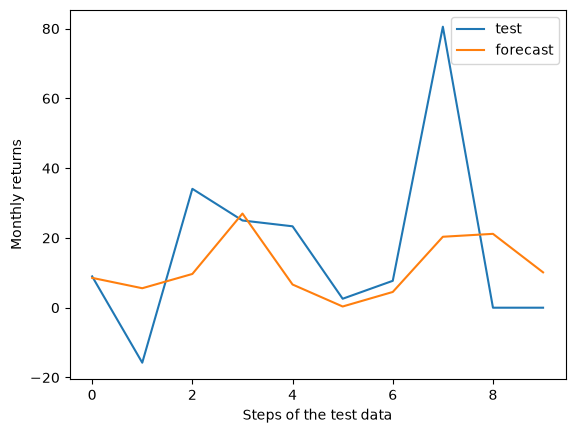

r2_score:  0.14248060935911533
rmse:  23.506693932696457


In [20]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=berger_end_month_df['returns'].dropna()[:-10]
y_test=berger_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(2,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))

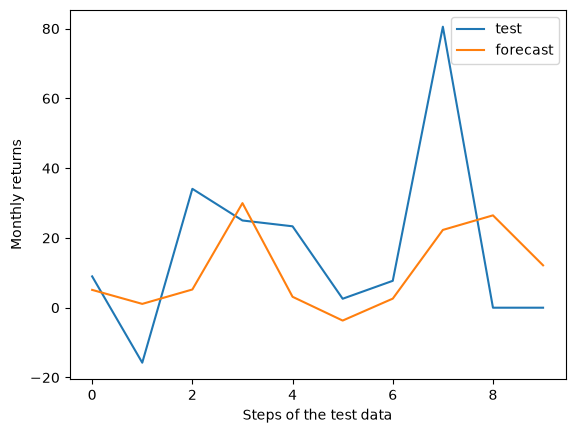

r2_score:  0.08871377304715089
rmse:  24.232430801686796


In [22]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=berger_end_month_df['returns'].dropna()[:-10]
y_test=berger_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,2), 
seasonal_order=(2,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))

This is not a good model.